In [1]:
from datasets import load_from_disk
dataset = load_from_disk("data/unified_dataset")

train_ds = dataset["train"]
val_ds = dataset["validation"]

In [13]:
train_ds[0]

{'id': 'qa_0046184',
 'split': 'train',
 'task': 'qa',
 'source_text': "In 1951, the Conservative Party returned to power in Britain, under the leadership of Winston Churchill. Churchill and the Conservatives believed that Britain's position as a world power relied on the continued existence of the empire, with the base at the Suez Canal allowing Britain to maintain its pre-eminent position in the Middle East in spite of the loss of India. However, Churchill could not ignore Gamal Abdul Nasser's new revolutionary government of Egypt that had taken power in 1952, and the following year it was agreed that British troops would withdraw from the Suez Canal zone and that Sudan would be granted self-determination by 1955, with independence to follow. Sudan was granted independence on 1 January 1956.",
 'question': 'Who ruled Egypt in 1952?',
 'answer': 'Gamal Abdul Nasser'}

In [14]:
train_ds.column_names


['id', 'split', 'task', 'source_text', 'question', 'answer']

In [15]:
narrative = train_ds.filter(lambda x: x['task'] != "qa")
qa = train_ds.filter(lambda x: x['task'] == "qa")

In [16]:
qa[0]

{'id': 'qa_0046184',
 'split': 'train',
 'task': 'qa',
 'source_text': "In 1951, the Conservative Party returned to power in Britain, under the leadership of Winston Churchill. Churchill and the Conservatives believed that Britain's position as a world power relied on the continued existence of the empire, with the base at the Suez Canal allowing Britain to maintain its pre-eminent position in the Middle East in spite of the loss of India. However, Churchill could not ignore Gamal Abdul Nasser's new revolutionary government of Egypt that had taken power in 1952, and the following year it was agreed that British troops would withdraw from the Suez Canal zone and that Sudan would be granted self-determination by 1955, with independence to follow. Sudan was granted independence on 1 January 1956.",
 'question': 'Who ruled Egypt in 1952?',
 'answer': 'Gamal Abdul Nasser'}

In [17]:
narrative[0]

{'id': 'narrative_0202626',
 'split': 'train',
 'task': 'narrative',
 'source_text': 'I\'ve always been fascinated by niche topics, especially those relating to true crime and serial killers. It might seem odd to some, but there\'s something about understanding the minds of these notorious figures that has intrigued me for years. So, when I decided to pursue my Master\'s degree in psychology, I knew exactly what area I wanted to specialize in.\n\nDuring my studies, I came across "The Bell Jar" by Sylvia Plath, which offered a hauntingly accurate depiction of mental illness. As an aspiring psychologist, I found myself deeply engrossed in Esther\'s journey – it felt as if I were living alongside her, feeling every emotion she experienced. Little did I know, my own world would soon come crashing down just like Esther\'s did.\n\nTowards the end of my graduate program, I had grown increasingly anxious about finding a job in my field. Despite countless applications and interviews, nothing se

In [3]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('/Users/kirill/My Folder/study/thesis/all_code_and_stuff/experiments/model_cache/Qwen--Qwen3-0.6B')

tokenizer.encode('1', add_special_tokens=False)

[16]

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datasets import concatenate_datasets
from tqdm.auto import tqdm

# Объединяем train + validation для полной картины
full_ds = concatenate_datasets([dataset["train"], dataset["validation"]])

narrative_ds = full_ds.filter(lambda x: x["task"] == "narrative")
qa_ds        = full_ds.filter(lambda x: x["task"] == "qa")

n_narrative = len(narrative_ds)
n_qa        = len(qa_ds)
n_total     = len(full_ds)

print(f"Всего    : {n_total:,}")
print(f"Narrative: {n_narrative:,}  ({n_narrative/n_total*100:.1f}%)")
print(f"QA       : {n_qa:,}  ({n_qa/n_total*100:.1f}%)")

Filter:   0%|          | 0/790918 [00:00<?, ? examples/s]

Filter:   0%|          | 0/790918 [00:00<?, ? examples/s]

Всего    : 790,918
Narrative: 600,000  (75.9%)
QA       : 190,918  (24.1%)


In [11]:
def tok_lengths(texts):
    # Calling tokenizer() directly handles a list of strings natively
    encodings = tokenizer(
        texts, 
        add_special_tokens=False, 
        padding=False, 
        truncation=False
    )
    return np.array([len(ids) for ids in encodings['input_ids']])

def to_list(col):
    return [k for k in col]
# Your existing calls remain exactly the same:
narrative_src_tok = tok_lengths(to_list(narrative_ds["source_text"]))
qa_src_tok        = tok_lengths(to_list(qa_ds["source_text"]))
# narrative_ans_tok = tok_lengths(narrative_ds["answer"])
qa_ans_tok        = tok_lengths(to_list(qa_ds["answer"]))
qa_q_tok          = tok_lengths(to_list(qa_ds["question"]))


In [ ]:
def tok_lengths(texts):
    out = []
    for t in tqdm(texts, leave=False):
        out.append(len(tokenizer.encode(t, add_special_tokens=False)))
    return np.array(out)

narrative_src_tok = tok_lengths(narrative_ds["source_text"])
qa_src_tok        = tok_lengths(qa_ds["source_text"])
narrative_ans_tok = tok_lengths(narrative_ds["answer"])
qa_ans_tok        = tok_lengths(qa_ds["answer"])
qa_q_tok          = tok_lengths(qa_ds["question"])

def stats(name, arr):
    print(f"{name:35s}  среднее={arr.mean():.0f}  медиана={np.median(arr):.0f}  "
          f"p95={np.percentile(arr,95):.0f}  макс={arr.max()}")

print("─" * 75)
stats("narrative — source_text", narrative_src_tok)
stats("qa        — source_text", qa_src_tok)
print()
stats("narrative — answer",      narrative_ans_tok)
stats("qa        — answer",      qa_ans_tok)
stats("qa        — question",    qa_q_tok)
print("─" * 75)

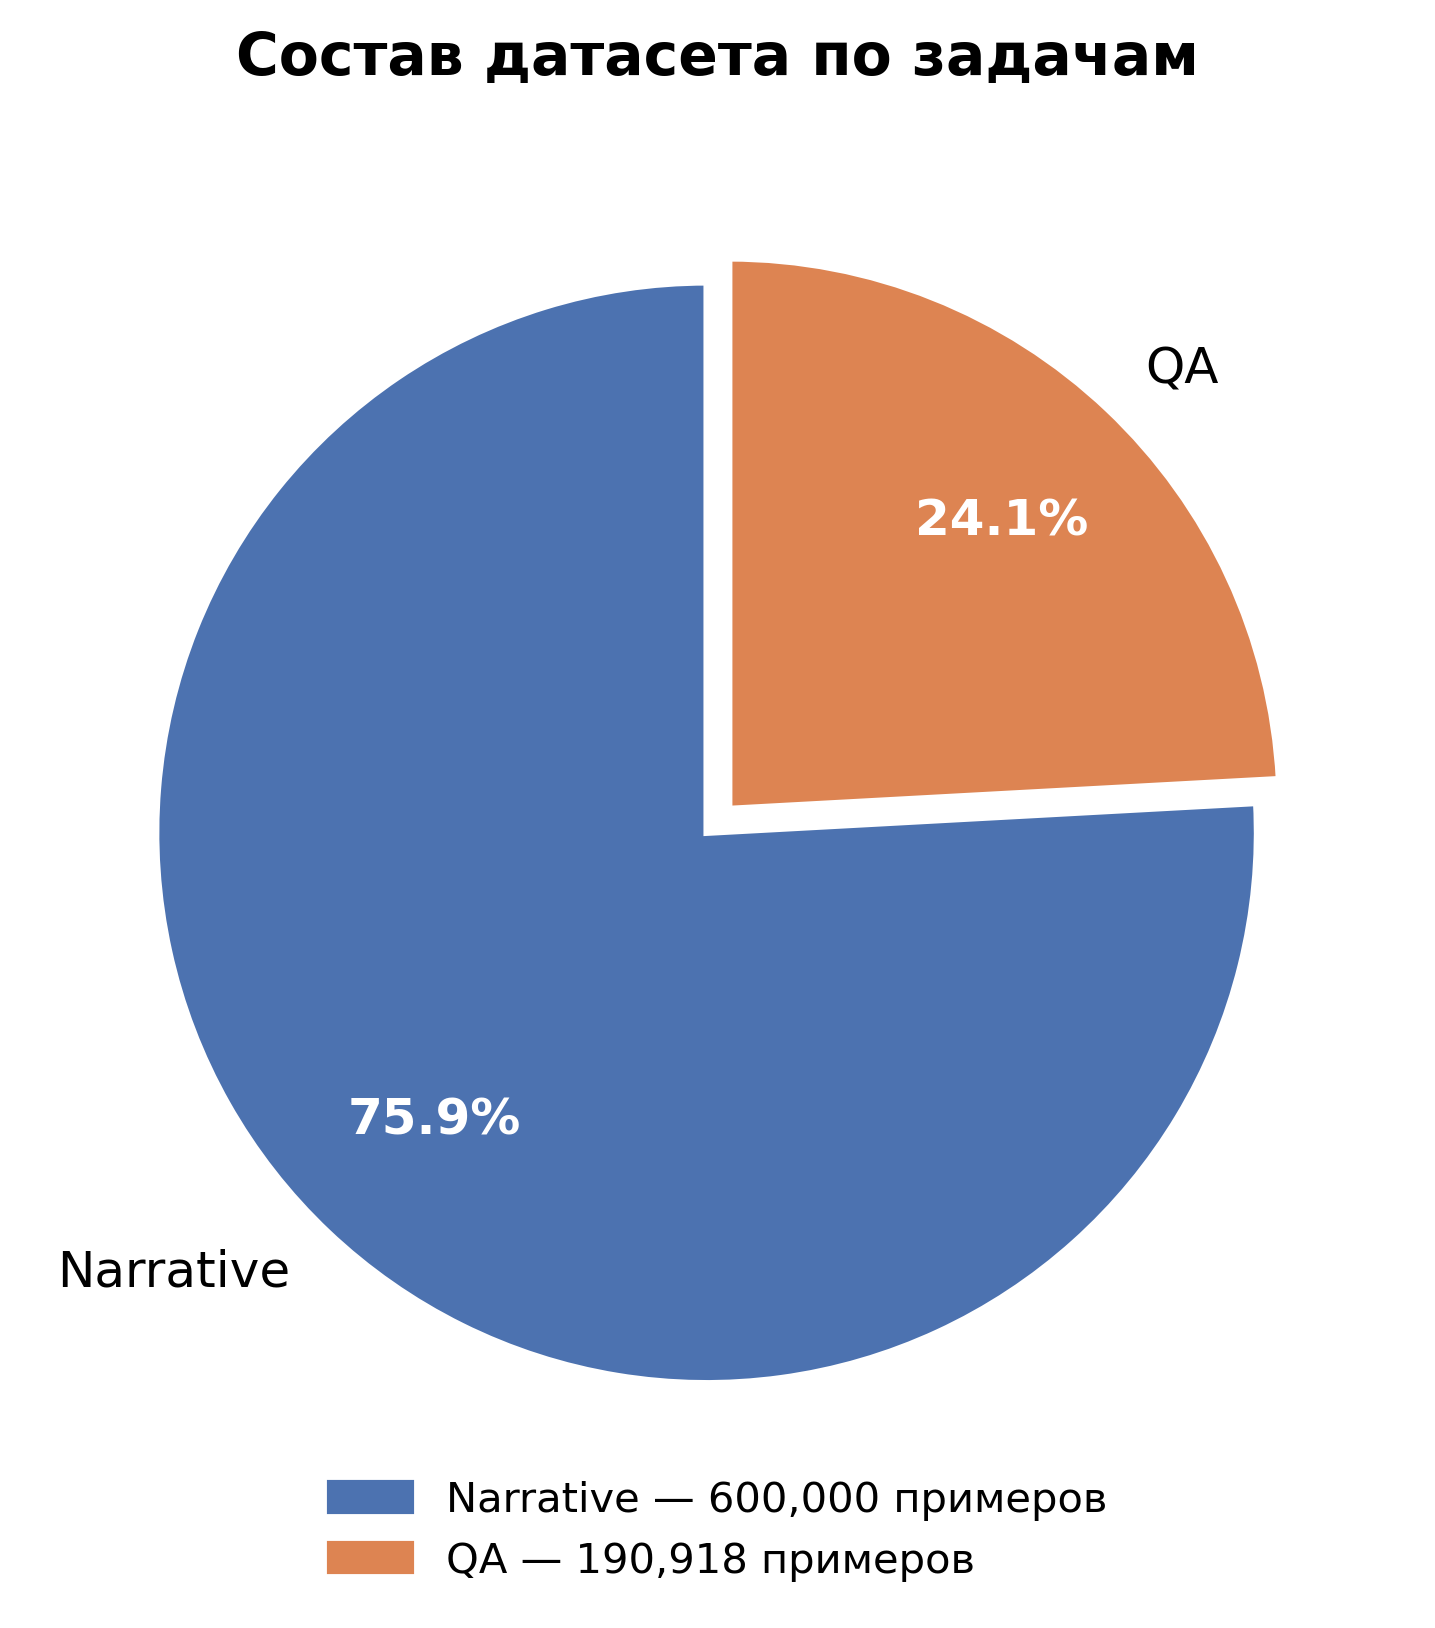

Сохранено → fig_dataset_composition.png


In [12]:
# ── Общие настройки стиля ────────────────────────────────────────────────────
PLT_STYLE   = "seaborn-v0_8-whitegrid"
C_NARRATIVE = "#4C72B0"
C_QA        = "#DD8452"
DPI         = 300
FONT_TITLE  = 14
FONT_LABEL  = 12
FONT_TICK   = 10

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# ── Рисунок 1 — Круговая диаграмма: состав датасета ─────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=DPI)

sizes   = [n_narrative, n_qa]
labels  = ["Narrative", "QA"]
colors  = [C_NARRATIVE, C_QA]
explode = (0.03, 0.03)

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=explode,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.72,
    wedgeprops=dict(linewidth=1.5, edgecolor="white"),
    textprops=dict(fontsize=FONT_LABEL),
)
for at in autotexts:
    at.set_fontsize(FONT_LABEL)
    at.set_fontweight("bold")
    at.set_color("white")

ax.set_title("Состав датасета по задачам", fontsize=FONT_TITLE, fontweight="bold", pad=14)

legend_labels  = [f"{l} — {n:,} примеров" for l, n in zip(labels, sizes)]
legend_patches = [mpatches.Patch(color=c, label=lb) for c, lb in zip(colors, legend_labels)]
ax.legend(handles=legend_patches, loc="lower center", bbox_to_anchor=(0.5, -0.08),
          fontsize=FONT_TICK, frameon=False)

plt.tight_layout()
plt.savefig("fig_dataset_composition.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("Сохранено → fig_dataset_composition.png")

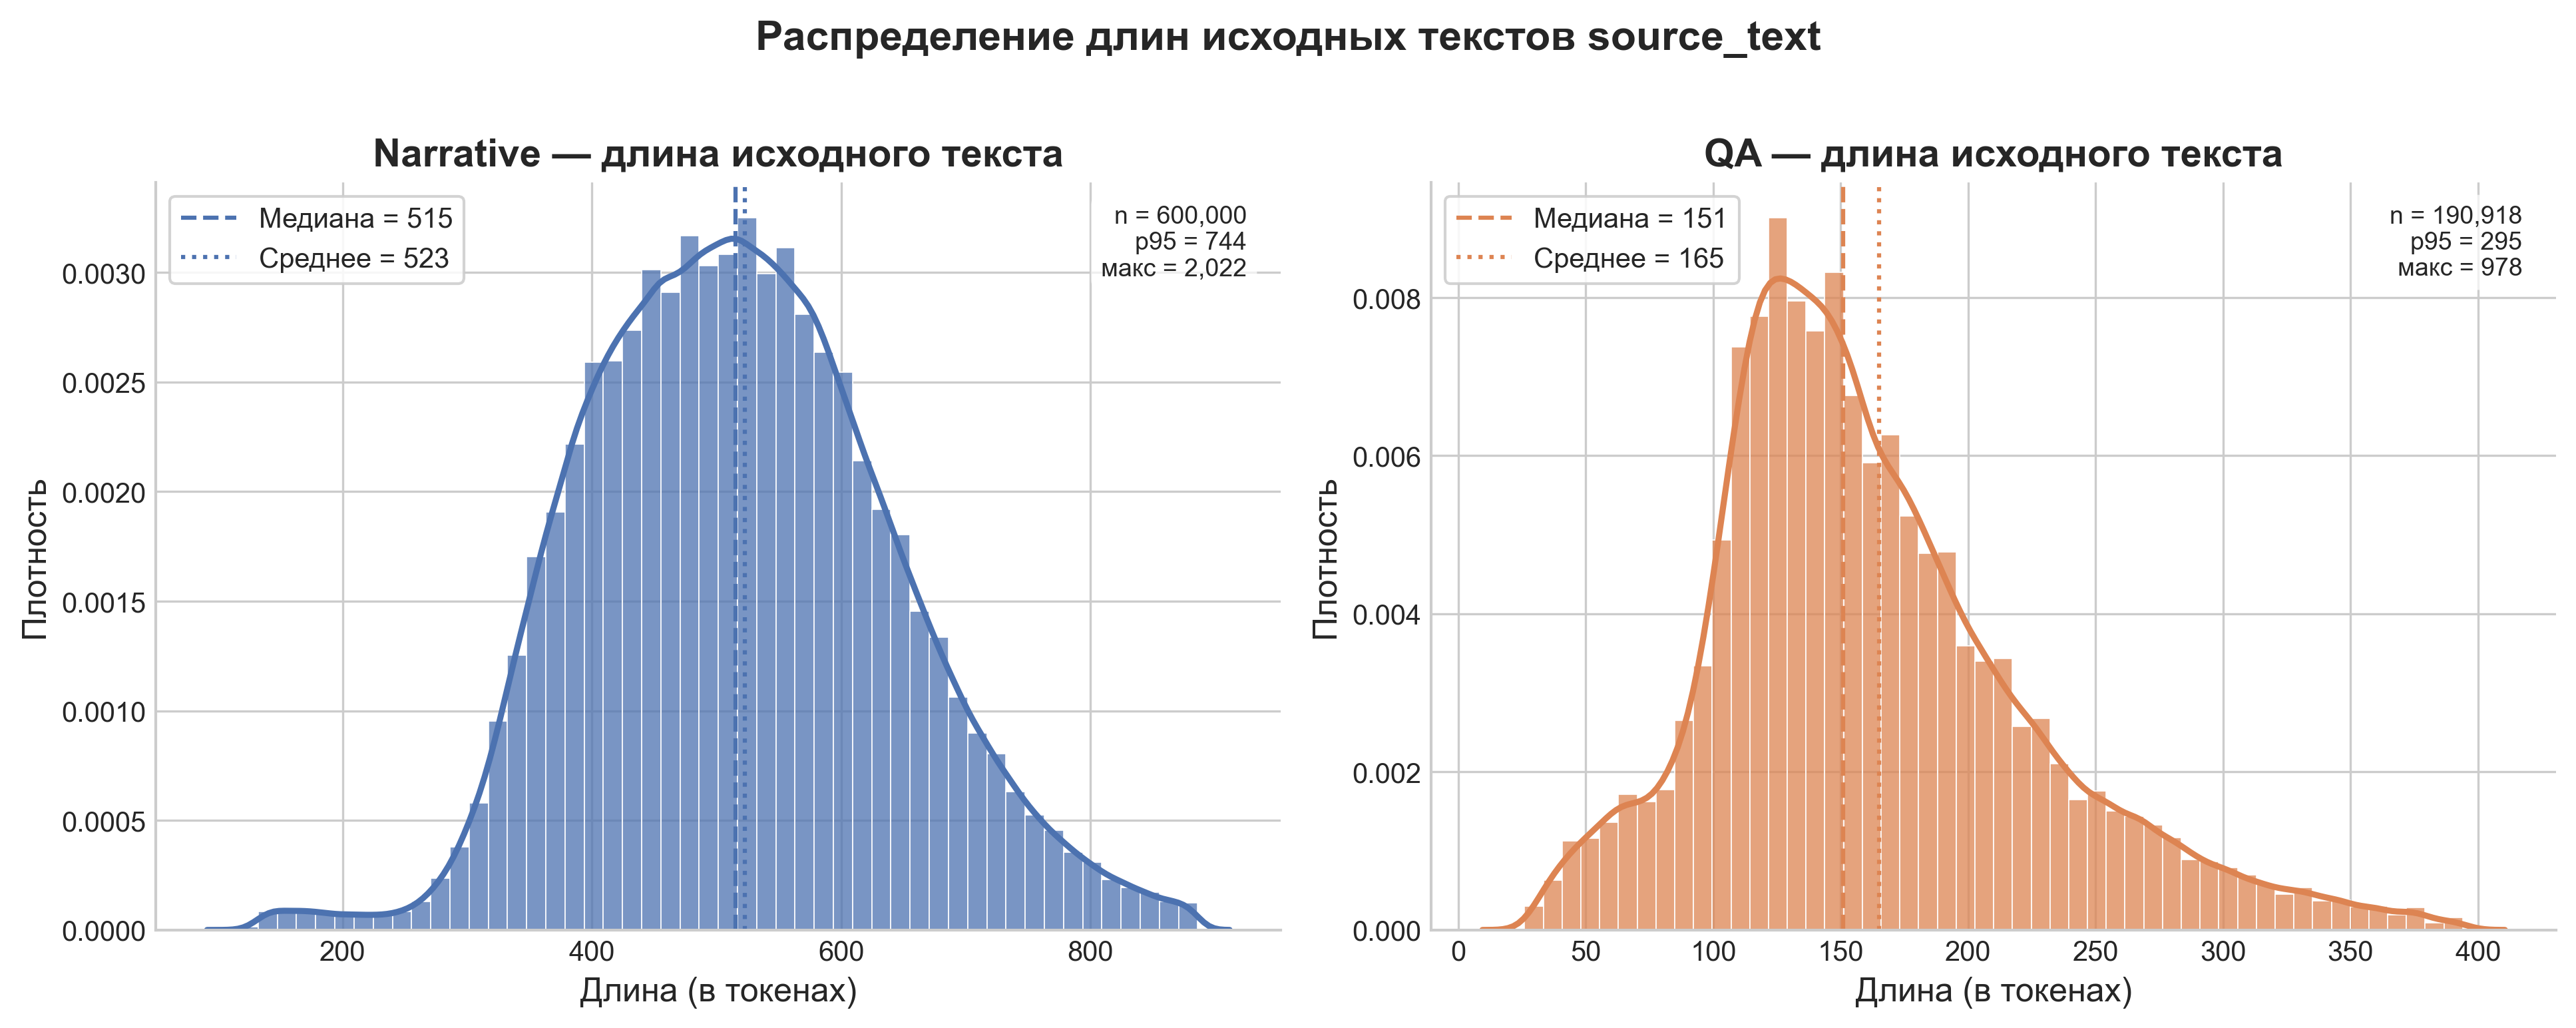

Сохранено → fig_source_length_dist.png


In [14]:
# ── Рисунок 2 — Распределение длин исходных текстов (токены) ────────────────
with plt.style.context(PLT_STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=DPI)

    for ax, arr, color, label, clip in [
        (axes[0], narrative_src_tok, C_NARRATIVE, "Narrative", (0, np.percentile(narrative_src_tok, 99))),
        (axes[1], qa_src_tok,        C_QA,        "QA",        (0, np.percentile(qa_src_tok, 99))),
    ]:
        arr_clip = arr[arr <= clip[1]]
        sns.histplot(arr_clip, ax=ax, color=color, alpha=0.75,
                     bins=50, stat="density", edgecolor="white", linewidth=0.4)
        sns.kdeplot(arr_clip, ax=ax, color=color, linewidth=2.2)

        med = int(np.median(arr))
        mn  = int(arr.mean())
        ax.axvline(med, color=color, linestyle="--", linewidth=1.5, label=f"Медиана = {med}")
        ax.axvline(mn,  color=color, linestyle=":",  linewidth=1.5, label=f"Среднее = {mn}")

        ax.set_title(f"{label} — длина исходного текста", fontsize=FONT_TITLE, fontweight="bold")
        ax.set_xlabel("Длина (в токенах)", fontsize=FONT_LABEL)
        ax.set_ylabel("Плотность",      fontsize=FONT_LABEL)
        ax.tick_params(labelsize=FONT_TICK)
        ax.legend(fontsize=FONT_TICK, frameon=True, framealpha=0.85)

        note = (f"n = {len(arr):,}\n"
                f"p95 = {int(np.percentile(arr, 95)):,}\n"
                f"макс = {arr.max():,}")
        ax.text(0.97, 0.97, note, transform=ax.transAxes,
                va="top", ha="right", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.7, ec="none"))

    fig.suptitle("Распределение длин исходных текстов source_text",
                 fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("fig_source_length_dist.png", dpi=DPI, bbox_inches="tight")
    plt.show()
    print("Сохранено → fig_source_length_dist.png")

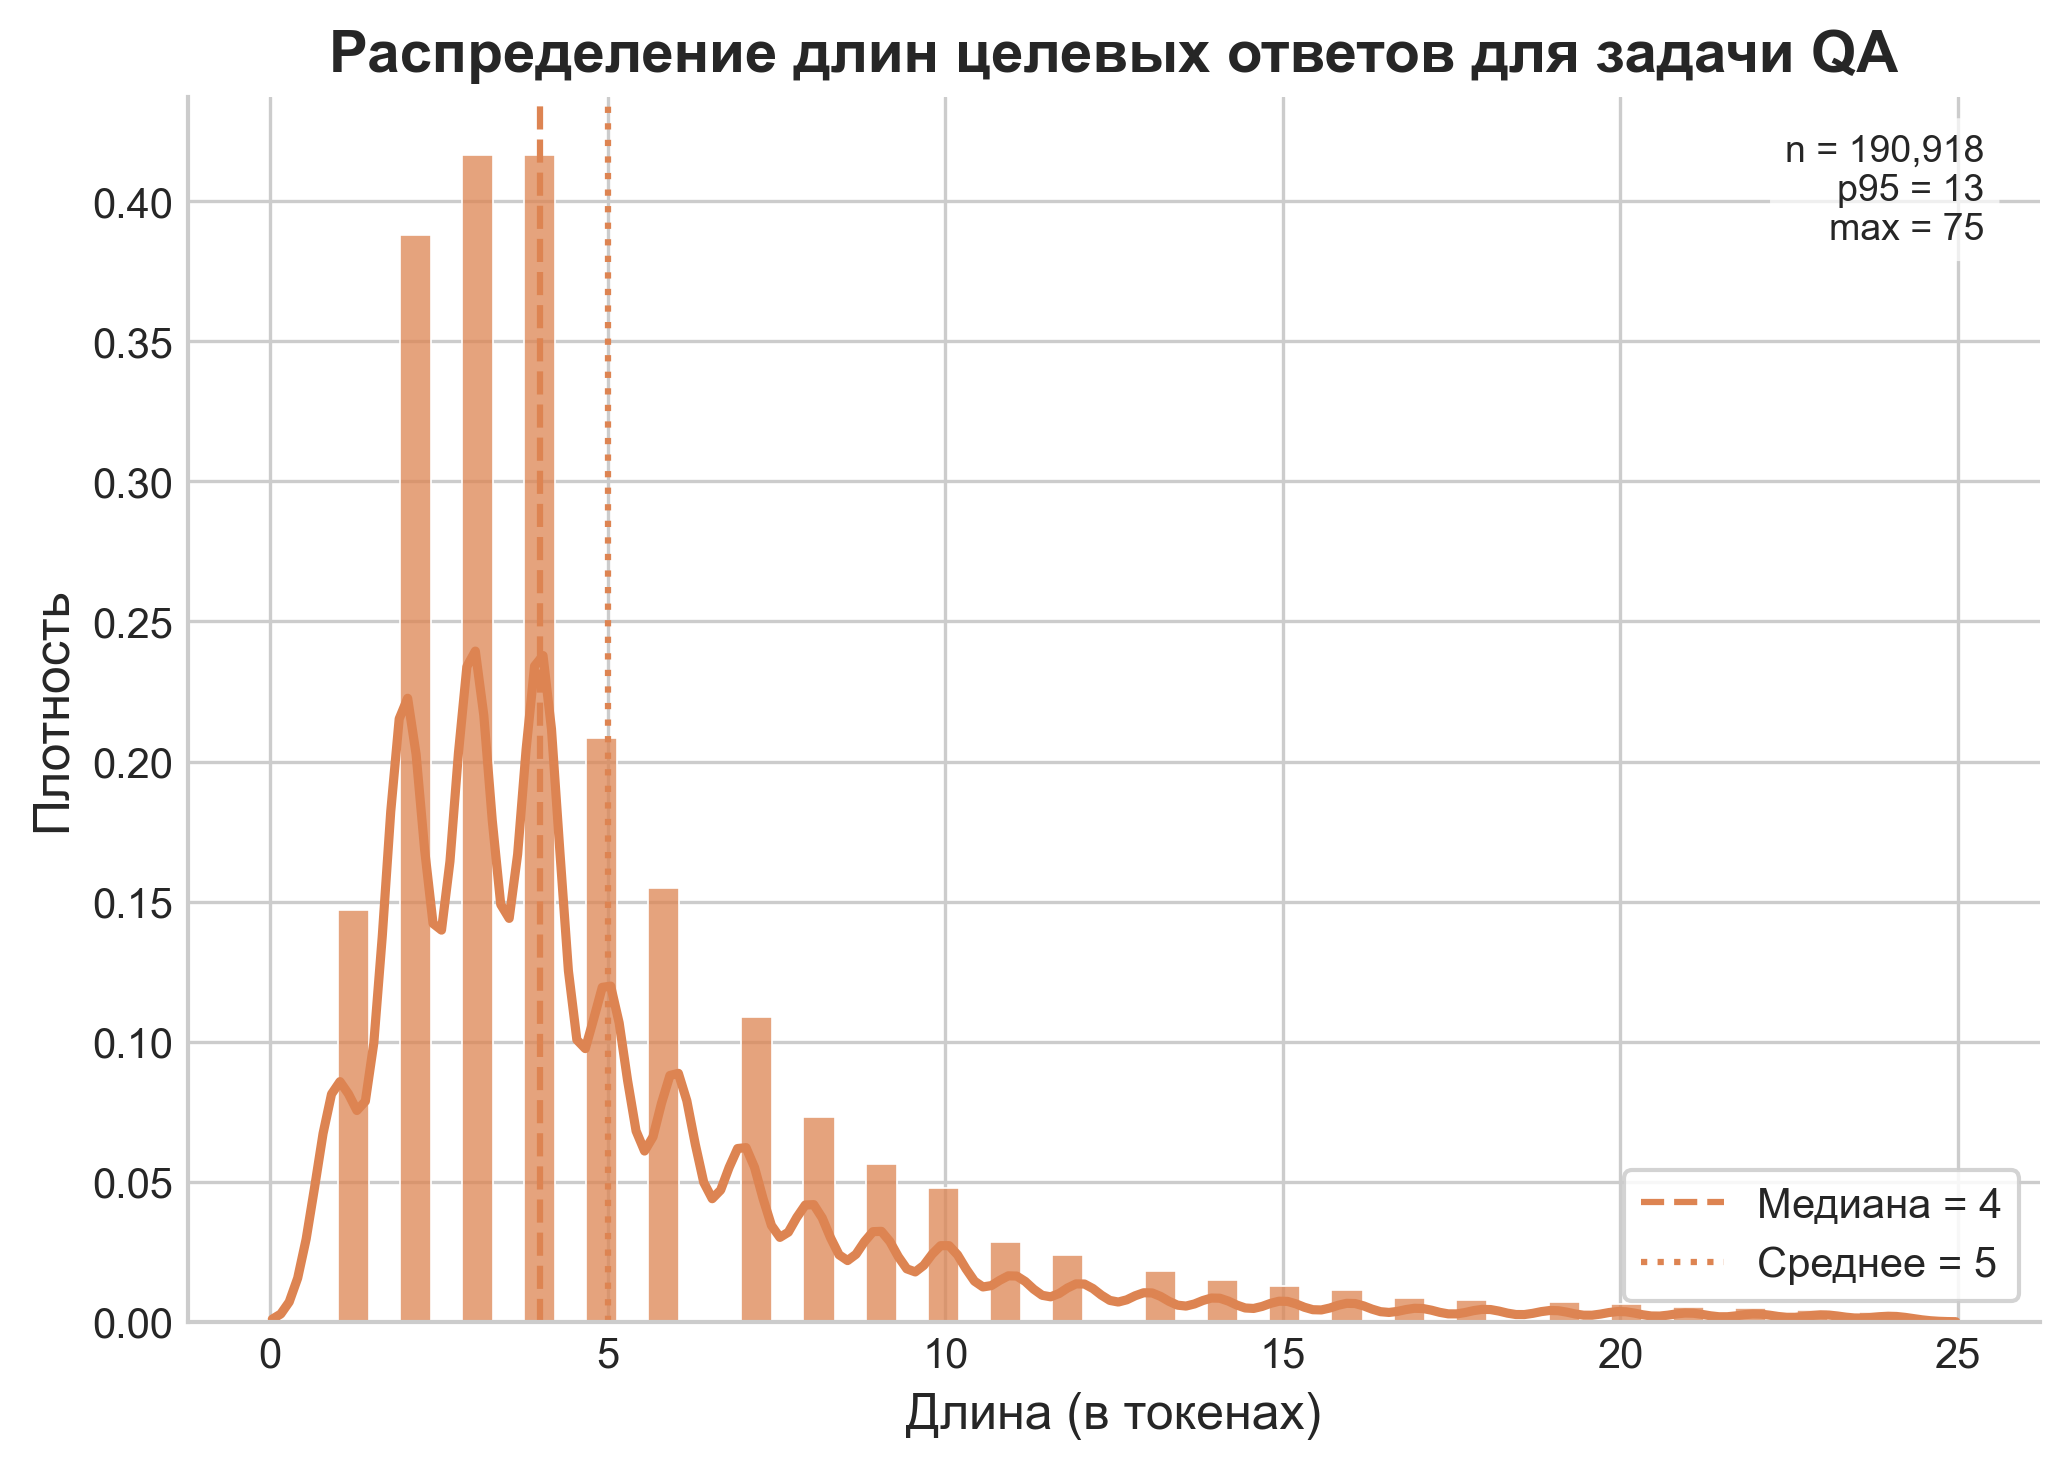

Сохранено → fig_answer_length_dist.png


In [15]:
# ── Рисунок 3 — Распределение длин ответов (токены), только QA ──────────────
with plt.style.context(PLT_STYLE):
    fig, ax = plt.subplots(figsize=(7, 5), dpi=DPI)

    arr      = qa_ans_tok
    arr_clip = arr[arr <= np.percentile(arr, 99)]

    sns.histplot(arr_clip, ax=ax, color=C_QA, alpha=0.75,
                 bins=50, stat="density", edgecolor="white", linewidth=0.4)
    sns.kdeplot(arr_clip, ax=ax, color=C_QA, linewidth=2.2)

    med = int(np.median(arr))
    mn  = int(arr.mean())
    ax.axvline(med, color=C_QA, linestyle="--", linewidth=1.5, label=f"Медиана = {med}")
    ax.axvline(mn,  color=C_QA, linestyle=":",  linewidth=1.5, label=f"Среднее = {mn}")

    ax.set_title("Распределение длин целевых ответов для задачи QA",
                 fontsize=FONT_TITLE, fontweight="bold")
    ax.set_xlabel("Длина (в токенах)", fontsize=FONT_LABEL)
    ax.set_ylabel("Плотность",      fontsize=FONT_LABEL)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_TICK, frameon=True, framealpha=0.85)

    note = (f"n = {len(arr):,}\n"
            f"p95 = {int(np.percentile(arr, 95)):,}\n"
            f"max = {arr.max():,}")
    ax.text(0.97, 0.97, note, transform=ax.transAxes,
            va="top", ha="right", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.7, ec="none"))

    plt.tight_layout()
    plt.savefig("fig_answer_length_dist.png", dpi=DPI, bbox_inches="tight")
    plt.show()
    print("Сохранено → fig_answer_length_dist.png")

In [19]:
dataset.column_names

{'train': ['id', 'split', 'task', 'source_text', 'question', 'answer'],
 'validation': ['id', 'split', 'task', 'source_text', 'question', 'answer']}

NameError: name 'narrative_ans_tok' is not defined

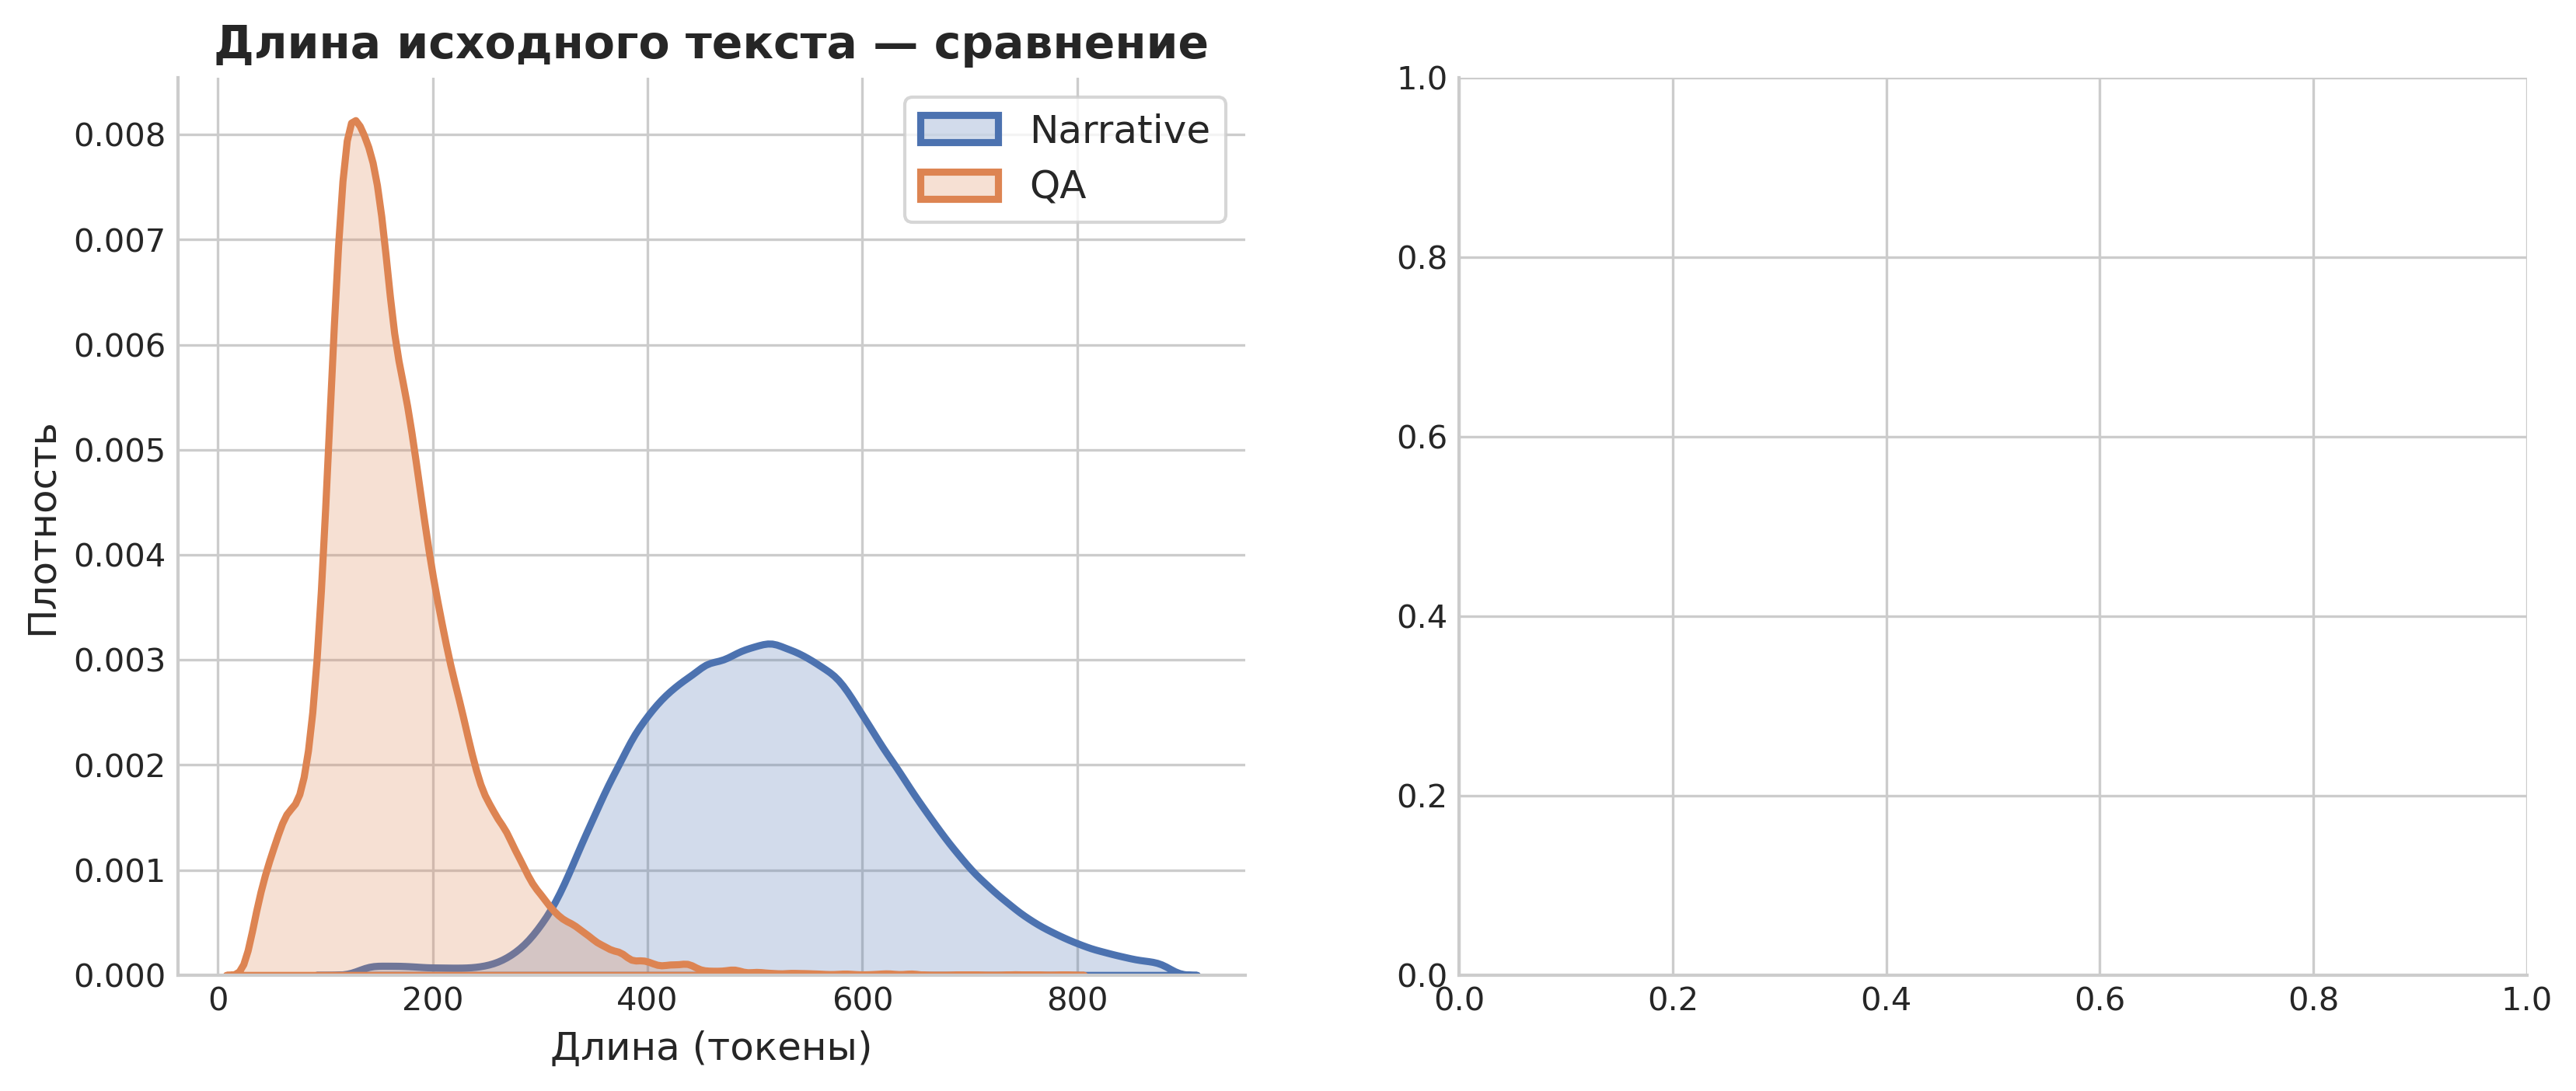

In [16]:
# ── Рисунок 4 — Сравнение задач на одной оси ────────────────────────────────
with plt.style.context(PLT_STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=DPI)

    # Левый: исходные тексты
    ax   = axes[0]
    clip = max(np.percentile(narrative_src_tok, 99), np.percentile(qa_src_tok, 99))

    sns.kdeplot(narrative_src_tok[narrative_src_tok <= clip], ax=ax,
                color=C_NARRATIVE, linewidth=2.2, fill=True, alpha=0.25, label="Narrative")
    sns.kdeplot(qa_src_tok[qa_src_tok <= clip], ax=ax,
                color=C_QA, linewidth=2.2, fill=True, alpha=0.25, label="QA")

    ax.set_title("Длина исходного текста — сравнение", fontsize=FONT_TITLE, fontweight="bold")
    ax.set_xlabel("Длина (токены)", fontsize=FONT_LABEL)
    ax.set_ylabel("Плотность",      fontsize=FONT_LABEL)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LABEL, frameon=True)

    # Правый: ответы
    ax     = axes[1]
    clip_n = np.percentile(narrative_ans_tok, 99)
    clip_q = np.percentile(qa_ans_tok, 99)
    ax2    = ax.twiny()

    sns.kdeplot(narrative_ans_tok[narrative_ans_tok <= clip_n], ax=ax,
                color=C_NARRATIVE, linewidth=2.2, fill=True, alpha=0.25, label="Narrative")
    sns.kdeplot(qa_ans_tok[qa_ans_tok <= clip_q], ax=ax,
                color=C_QA, linewidth=2.2, fill=True, alpha=0.25, label="QA")
    ax2.set_visible(False)

    ax.set_title("Длина ответа — сравнение", fontsize=FONT_TITLE, fontweight="bold")
    ax.set_xlabel("Длина (токены)", fontsize=FONT_LABEL)
    ax.set_ylabel("Плотность",      fontsize=FONT_LABEL)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LABEL, frameon=True)

    fig.suptitle("Narrative vs QA — сравнение длин",
                 fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("fig_length_overlay.png", dpi=DPI, bbox_inches="tight")
    plt.show()
    print("Сохранено → fig_length_overlay.png")

In [18]:
# ── Сводная таблица статистик ────────────────────────────────────────────────
rows = []
narrative_ans_tok = narrative_src_tok
for name, arr in [
    ("Narrative — исходный текст", narrative_src_tok),
    ("QA        — исходный текст", qa_src_tok),
    ("QA        — вопрос",         qa_q_tok),
    ("Narrative — ответ",          narrative_ans_tok),
    ("QA        — ответ",          qa_ans_tok),
]:
    rows.append({
        "Поле":     name,
        "Кол-во":   len(arr),
        "Среднее":  round(arr.mean(), 1),
        "Медиана":  int(np.median(arr)),
        "Ст. откл.": round(arr.std(), 1),
        "p95":      int(np.percentile(arr, 95)),
        "p99":      int(np.percentile(arr, 99)),
        "Макс":     int(arr.max()),
    })

df_stats = pd.DataFrame(rows).set_index("Поле")
print("Статистика длин в токенах (токенайзер Qwen3-Embedding-0.6B)\n")
print(df_stats.to_string())
df_stats

Статистика длин в токенах (токенайзер Qwen3-Embedding-0.6B)

                            Кол-во  Среднее  Медиана  Ст. откл.  p95  p99  Макс
Поле                                                                           
Narrative — исходный текст  600000    523.3      515      130.8  744  886  2022
QA        — исходный текст  190918    165.0      151       70.0  295  394   978
QA        — вопрос          190918     12.7       12        4.4   21   26    61
Narrative — ответ           600000    523.3      515      130.8  744  886  2022
QA        — ответ           190918      5.1        4        4.4   13   24    75


,Кол-во,Среднее,Медиана,Ст. откл.,p95,p99,Макс
Поле,,,,,,,
Narrative — исходный текст,600000,523.3,515,130.8,744,886,2022
QA — исходный текст,190918,165.0,151,70.0,295,394,978
QA — вопрос,190918,12.7,12,4.4,21,26,61
Narrative — ответ,600000,523.3,515,130.8,744,886,2022
QA — ответ,190918,5.1,4,4.4,13,24,75
